## EXPLORATORY DATA ANALYSIS ON A DATASET

### Objective:

In [1]:
## The main goal of this assignment is to conduct a thorough exploratory analysis of the "cardiographic.csv" dataset to uncover insights, ##identify patterns, and understand the dataset's underlying structure. You will use statistical summaries, visualizations, and data ##manipulation techniques to explore the dataset comprehensively.

## Dataset:
## 1.	LB - Likely stands for "Baseline Fetal Heart Rate (FHR)" which represents the average fetal heart rate over a period.
## 2.	AC - Could represent "Accelerations" in the FHR. Accelerations are usually a sign of fetal well-being.
## 3.	FM - May indicate "Fetal Movements" detected by the monitor.
## 4.	UC - Likely denotes "Uterine Contractions", which can impact the FHR pattern.
## 5.	DL - Could stand for "Decelerations Late" with respect to uterine contractions, which can be a sign of fetal distress.
## 6.	DS - May represent "Decelerations Short" or decelerations of brief duration.
## 7.	DP - Could indicate "Decelerations Prolonged", or long-lasting decelerations.
## 8.	ASTV - Might refer to "Percentage of Time with Abnormal Short Term Variability" in the FHR.
## 9.	MSTV - Likely stands for "Mean Value of Short Term Variability" in the FHR.
## 10.	ALTV - Could represent "Percentage of Time with Abnormal Long Term Variability" in the FHR.
## 11.	MLTV - Might indicate "Mean Value of Long Term Variability" in the FHR.

In [2]:
## Tools and Libraries:
## ●	Python or R programming language
## ●	Data manipulation libraries 
## ●	Data visualization libraries (Matplotlib and Seaborn in Python)
## ●	Jupyter Notebook for documenting your analysis

### 1.	Data Cleaning and Preparation:

In [3]:
## ●	Load the dataset into a DataFrame or equivalent data structure.
## ●	Handle missing values appropriately (e.g., imputation, deletion).
## ●	Identify and correct any inconsistencies in data types (e.g., numerical values stored as strings).
## ●	Detect and treat outliers if necessary.

In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("Cardiotocographic.csv")
## load the dataset into a pandas dataframe to allow data manipulation and analysis..

In [6]:
df.head()
## The head() function displays the first 5 rows to understand the structure of the dataset..

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [7]:
df.info()
## check the basic information..
## this helps us understand number of rows and column, datatype of each column, presence of missing values, 
## dataset has 2126 records, all variables are of float type, 
## some columns [LB, AC, DS, DP, MLTV, Width, Tendency, NSP] have some missing values..

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [8]:
df.isnull().sum()
## this shows how many missing values are present  in each column.

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

In [9]:
## since the number of missing value is quite small as compared to total rows, we will use mean imputation to fill the missing values..
## why mean imputation? because all columns are numerical, 
## it will preserve the dataset size and and avoids deletion of valuable medical data at the same time..

In [10]:
df.fillna(df.mean(), inplace = True)
## filling missing values with mean of that particular column..
## hence we eliminated all the null values..

In [11]:
## NSP seems to be the target variable, lets check its value counts..
df["NSP"].value_counts()

NSP
 1.000000    1546
 2.000000     280
 3.000000     164
 1.304507      21
-1.000000       5
             ... 
 0.992847       1
 2.971309       1
 0.984834       1
 0.991200       1
 1.990464       1
Name: count, Length: 112, dtype: int64

In [12]:
## here we can see that NSP contain lot of noice values apart from few pure categories (1,2 , 3)
## lets remove these noice and treat it as categorical variable for best possible analysis..
## we will do this by rounding the noicy values..

In [13]:
df['NSP'] = df['NSP'].round()

In [14]:
df["NSP"].value_counts()

NSP
 1.0    1651
 2.0     293
 3.0     172
-1.0       6
 5.0       4
Name: count, dtype: int64

In [15]:
## upon googling about the data what we find out was only three valid classes are there for NSP..
## 1 -> Normal, 2 -> Suspect, 3 -> Pathologic..
## we still have -1 and 5, which seems to be invalid catogories.. since they are in very low number, lets remove them..
df = df[df["NSP"].isin([1.0, 2.0, 3.0])]

In [16]:
## checking again..
df["NSP"].value_counts()

NSP
1.0    1651
2.0     293
3.0     172
Name: count, dtype: int64

In [17]:
## now we have cleaned, noiceless target variable..
## the reason we removed instead of imputation because it is class label, we can't replace values with mean or randomly..

In [18]:
## convert NSP to categorical column
df['NSP'] = df['NSP'].astype('category')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2116 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   LB        2116 non-null   float64 
 1   AC        2116 non-null   float64 
 2   FM        2116 non-null   float64 
 3   UC        2116 non-null   float64 
 4   DL        2116 non-null   float64 
 5   DS        2116 non-null   float64 
 6   DP        2116 non-null   float64 
 7   ASTV      2116 non-null   float64 
 8   MSTV      2116 non-null   float64 
 9   ALTV      2116 non-null   float64 
 10  MLTV      2116 non-null   float64 
 11  Width     2116 non-null   float64 
 12  Tendency  2116 non-null   float64 
 13  NSP       2116 non-null   category
dtypes: category(1), float64(13)
memory usage: 233.6 KB


In [20]:
## for outlier detection we will use boxplot and IQR method..

In [21]:
## select numerical columns only 
num_cols = df.select_dtypes(include = 'float64').columns
num_cols

Index(['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV',
       'MLTV', 'Width', 'Tendency'],
      dtype='object')

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns


Column: LB
Q1 : 126.0
Q3 : 140.0
IQR : 14.0
Lower Bound : 105.0
Upper Bound : 161.0
Minimum Value : 51.84248683343552
Maximum Value : 214.0
Potential Outiers : 10


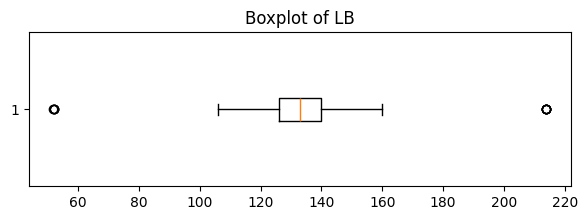

****************************************************************************************************

Column: AC
Q1 : 0.0
Q3 : 0.005578804
IQR : 0.005578804
Lower Bound : -0.008368206
Upper Bound : 0.01394701
Minimum Value : -0.019283747
Maximum Value : 0.038567494
Potential Outiers : 43


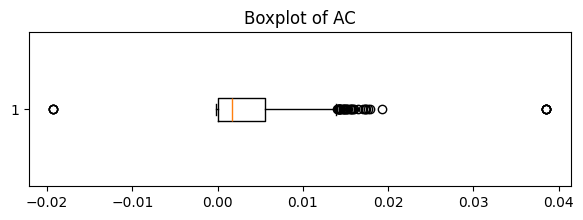

****************************************************************************************************

Column: FM
Q1 : 0.0
Q3 : 0.00256492575
IQR : 0.00256492575
Lower Bound : -0.003847388625
Upper Bound : 0.006412314375
Minimum Value : -0.480633803
Maximum Value : 0.961267606
Potential Outiers : 344


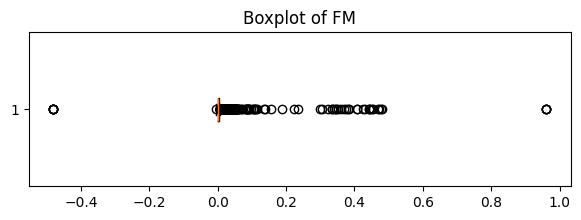

****************************************************************************************************

Column: UC
Q1 : 0.0018407745
Q3 : 0.006535948
IQR : 0.0046951735
Lower Bound : -0.005201985750000001
Upper Bound : 0.01357870825
Minimum Value : -0.014925373
Maximum Value : 0.0300018264803428
Potential Outiers : 13


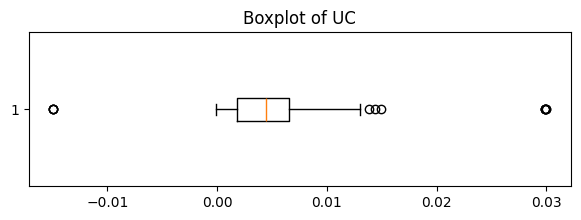

****************************************************************************************************

Column: DL
Q1 : 0.0
Q3 : 0.003289474
IQR : 0.003289474
Lower Bound : -0.004934211
Upper Bound : 0.008223685
Minimum Value : -0.015393469
Maximum Value : 0.03076923
Potential Outiers : 123


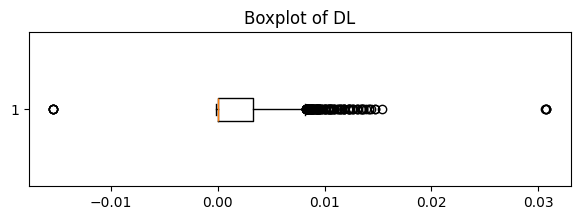

****************************************************************************************************

Column: DS
Q1 : 0.0
Q3 : 0.0
IQR : 0.0
Lower Bound : 0.0
Upper Bound : 0.0
Minimum Value : -0.00135318
Maximum Value : 0.00270636
Potential Outiers : 141


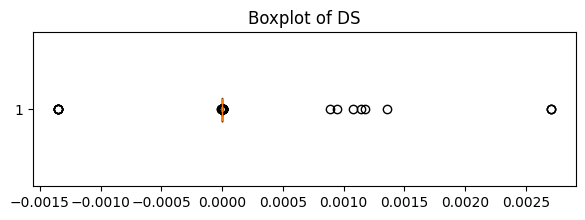

****************************************************************************************************

Column: DP
Q1 : 0.0
Q3 : 0.0
IQR : 0.0
Lower Bound : 0.0
Upper Bound : 0.0
Minimum Value : -0.005347594
Maximum Value : 0.010695188
Potential Outiers : 304


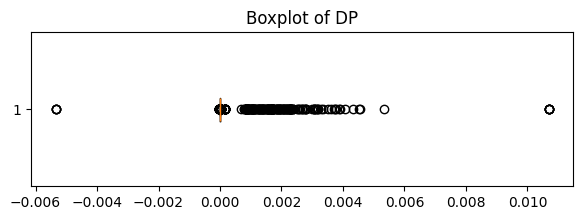

****************************************************************************************************

Column: ASTV
Q1 : 32.0
Q3 : 61.0
IQR : 29.0
Lower Bound : -11.5
Upper Bound : 104.5
Minimum Value : -63.0
Maximum Value : 162.0
Potential Outiers : 10


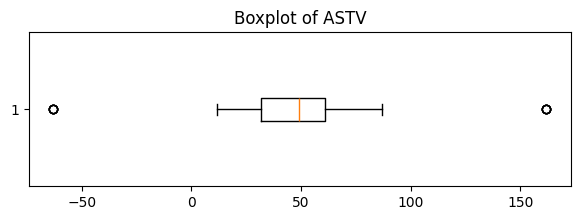

****************************************************************************************************

Column: MSTV
Q1 : 0.7
Q3 : 1.7
IQR : 1.0
Lower Bound : -0.8
Upper Bound : 3.2
Minimum Value : -6.6
Maximum Value : 13.8
Potential Outiers : 79


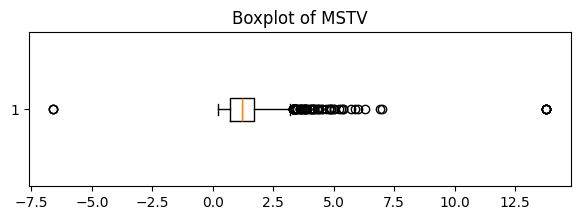

****************************************************************************************************

Column: ALTV
Q1 : 0.0
Q3 : 11.0
IQR : 11.0
Lower Bound : -16.5
Upper Bound : 27.5
Minimum Value : -91.0
Maximum Value : 182.0
Potential Outiers : 318


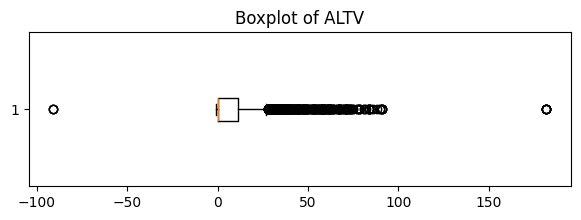

****************************************************************************************************

Column: MLTV
Q1 : 4.6
Q3 : 10.8
IQR : 6.200000000000001
Lower Bound : -4.700000000000001
Upper Bound : 20.1
Minimum Value : -50.7
Maximum Value : 101.4
Potential Outiers : 80


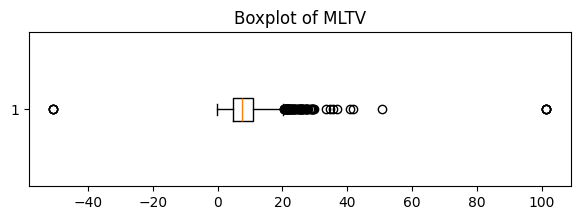

****************************************************************************************************

Column: Width
Q1 : 37.0
Q3 : 100.0
IQR : 63.0
Lower Bound : -57.5
Upper Bound : 194.5
Minimum Value : -174.0
Maximum Value : 357.0
Potential Outiers : 10


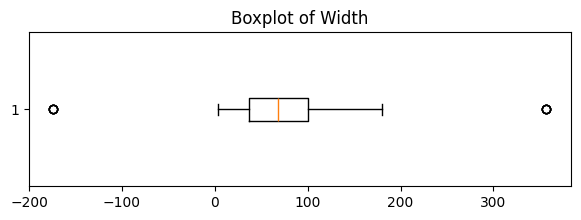

****************************************************************************************************

Column: Tendency
Q1 : 0.0
Q3 : 1.0
IQR : 1.0
Lower Bound : -1.5
Upper Bound : 2.5
Minimum Value : -3.0
Maximum Value : 3.0
Potential Outiers : 10


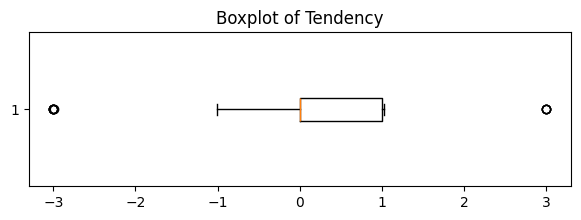

****************************************************************************************************


In [23]:
for i in num_cols:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    min_val = df[i].min()
    max_val = df[i].max()

    ## detect outliers..
    outliers = df[(df[i] < lower_bound) | (df[i] > upper_bound)][i]

    print(f"\nColumn: {i}")
    print(f"Q1 : {Q1}")
    print(f"Q3 : {Q3}")
    print(f"IQR : {IQR}")
    print(f"Lower Bound : {lower_bound}")
    print(f"Upper Bound : {upper_bound}")
    print(f"Minimum Value : {min_val}")
    print(f"Maximum Value : {max_val}")
    print(f"Potential Outiers : {len(outliers)}")
## Undo and run the commented code to see the potential outliers 
##    if len(outliers) > 0:
##        print("Potential Outliers:")
##        print(outliers.values)
    
    plt.figure(figsize = (7, 2))
    plt.boxplot(df[i].dropna(), vert = False)
    plt.title(f"Boxplot of {i}")
    plt.show()

    print("*"*100)

In [24]:
## The IQR method and boxplot method was used to detect the presence of outliers in the dataset..
## The result showed us that several variable (except LB, UC, ASTV, Width and Tendency) contain a large number of outliers..
## However upon further inspection that i did in below cell revealed that many variables contain high number of 0 values.. 
## Also another reason is many columns like (AC, FM, UC, DL, DS, DP) has values very close to 0 in decimals..
## Also if we look closely to df.describe(), its evident because for most of the columns; mean,min amd max values are very close to 0
## So this the reason most values were flagged as outliers in the dataset..

## Since this dataset belongs to medical field, they likely represent valid medical measurements..
## So removing them could result in loss of important information..
## Therefore instead of removing them, we will retain them for further analysis..

## This shows that dataset maybe highly skewed..

In [25]:
for i in num_cols:
    print(f"{i}: ",df[df[i] == 0].value_counts().sum())

LB:  0
AC:  832
FM:  1229
UC:  317
DL:  1161
DS:  1975
DP:  1812
ASTV:  0
MSTV:  0
ALTV:  1162
MLTV:  123
Width:  0
Tendency:  1031


In [26]:
df.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency
count,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000,2116.000000
mean,133.350893,0.003210,0.009896,0.004385,0.001900,0.000003,0.000175,47.024461,1.362934,10.298185,8.315941,70.293072,0.315985
std,11.232655,0.004371,0.067688,0.003338,0.003322,0.000141,0.000836,18.839486,1.171244,21.243327,7.634543,42.714451,0.643042
min,51.842487,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-3.000000
25%,126.000000,0.000000,0.000000,0.001841,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000
50%,133.000000,0.001668,0.000000,0.004481,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.500000,68.000000,0.000000
75%,140.000000,0.005579,0.002565,0.006536,0.003289,0.000000,0.000000,61.000000,1.700000,11.000000,10.800000,100.000000,1.000000
max,214.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,3.000000


## 2.	Statistical Summary:

In [27]:
## ●	Provide a statistical summary for each variable in the dataset, including measures of central tendency (mean, median) and dispersion ## (standard deviation, interquartile range).
## ●	Highlight any interesting findings from this summary.

In [28]:
df.select_dtypes(include = 'float64').mean()

LB          133.350893
AC            0.003210
FM            0.009896
UC            0.004385
DL            0.001900
DS            0.000003
DP            0.000175
ASTV         47.024461
MSTV          1.362934
ALTV         10.298185
MLTV          8.315941
Width        70.293072
Tendency      0.315985
dtype: float64

In [29]:
df.select_dtypes(include = 'float64').median()

LB          133.000000
AC            0.001668
FM            0.000000
UC            0.004481
DL            0.000000
DS            0.000000
DP            0.000000
ASTV         49.000000
MSTV          1.200000
ALTV          0.000000
MLTV          7.500000
Width        68.000000
Tendency      0.000000
dtype: float64

In [30]:
df.select_dtypes(include = 'float64').std()

LB          11.232655
AC           0.004371
FM           0.067688
UC           0.003338
DL           0.003322
DS           0.000141
DP           0.000836
ASTV        18.839486
MSTV         1.171244
ALTV        21.243327
MLTV         7.634543
Width       42.714451
Tendency     0.643042
dtype: float64

In [31]:
for i in num_cols:
    print(f"Column: {i}")
    print(f"Q1 : {Q1}")
    print(f"Q3 : {Q3}")
    print(f"IQR : {IQR}")
    print(f"Lower Bound : {lower_bound}")
    print(f"Upper Bound : {upper_bound}")
    print(f"Minimum Value : {min_val}")
    print(f"Maximum Value : {max_val}")
    print(f"Potential Outiers : {len(outliers)}")
    print("*"*100)

Column: LB
Q1 : 0.0
Q3 : 1.0
IQR : 1.0
Lower Bound : -1.5
Upper Bound : 2.5
Minimum Value : -3.0
Maximum Value : 3.0
Potential Outiers : 10
****************************************************************************************************
Column: AC
Q1 : 0.0
Q3 : 1.0
IQR : 1.0
Lower Bound : -1.5
Upper Bound : 2.5
Minimum Value : -3.0
Maximum Value : 3.0
Potential Outiers : 10
****************************************************************************************************
Column: FM
Q1 : 0.0
Q3 : 1.0
IQR : 1.0
Lower Bound : -1.5
Upper Bound : 2.5
Minimum Value : -3.0
Maximum Value : 3.0
Potential Outiers : 10
****************************************************************************************************
Column: UC
Q1 : 0.0
Q3 : 1.0
IQR : 1.0
Lower Bound : -1.5
Upper Bound : 2.5
Minimum Value : -3.0
Maximum Value : 3.0
Potential Outiers : 10
****************************************************************************************************
Column: DL
Q1 : 0.0
Q3 : 1.0
IQR : 1

In [32]:
## conclusion.. 

## The average baseline fetal heart rate (LB) is around 133 bpm.. this falls under normal physiological range..
## Many variables such as AC, FM, and DS contain high number of 0 values.. this shows that these events in this particular medical case occurs infrequently..

## Comparing mean and median of columns like (LB, UC, DS, ASTV, MSTV, MLTV, Width), having similar mean and median suggests that distribution maybe symmetric..
## Rest of the columns have either slight left or right skewness..
## Using minimum and maximum values we can find the range, hence it will show us about the variability in distribution..
## Additionally the IQR and standard deviation highlights the variablity within the dataset..

## 3.	Data Visualization:

In [33]:
## ●	Create histograms or boxplots to visualize the distributions of various numerical variables.
## ●	Use bar charts or pie charts to display the frequency of categories for categorical variables.
## ●	Generate scatter plots or correlation heatmaps to explore relationships between pairs of variables.
## ●	Employ advanced visualization techniques like pair plots, or violin plots for deeper insights.

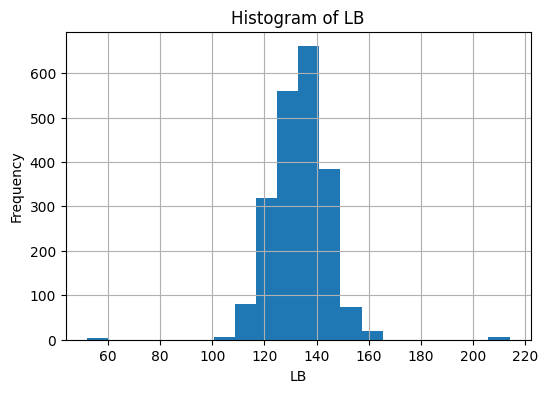

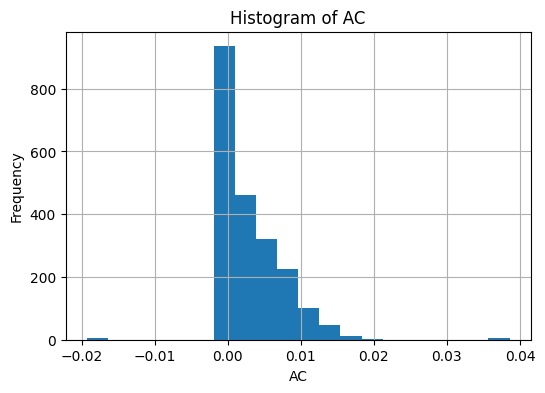

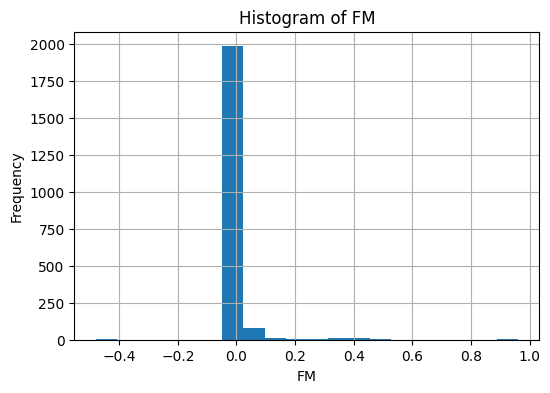

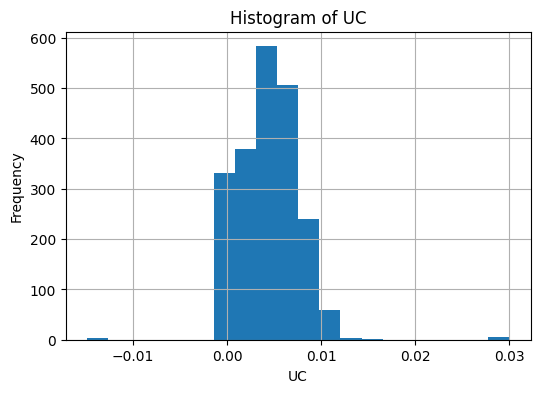

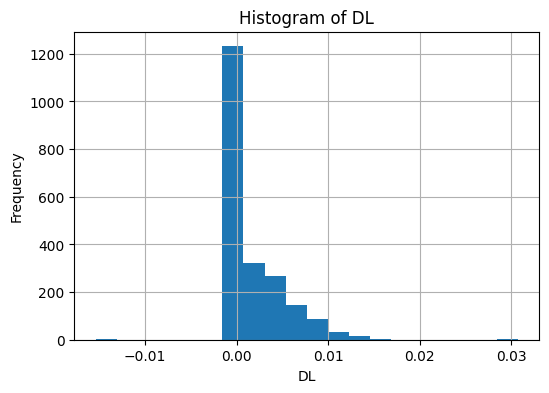

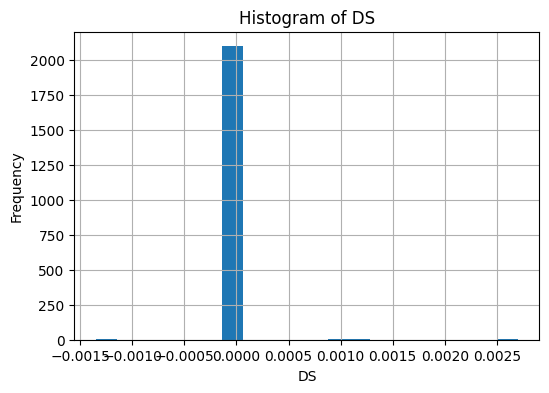

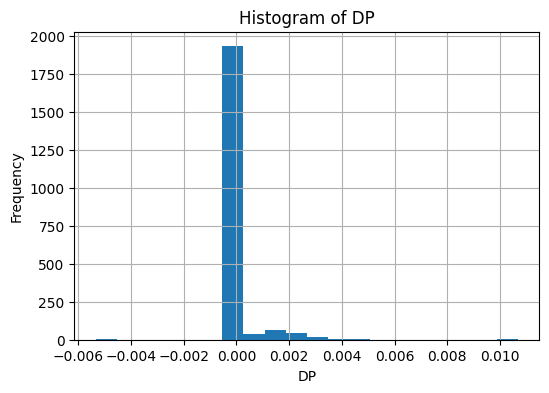

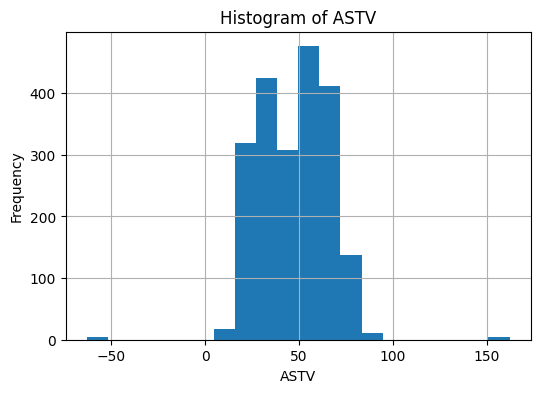

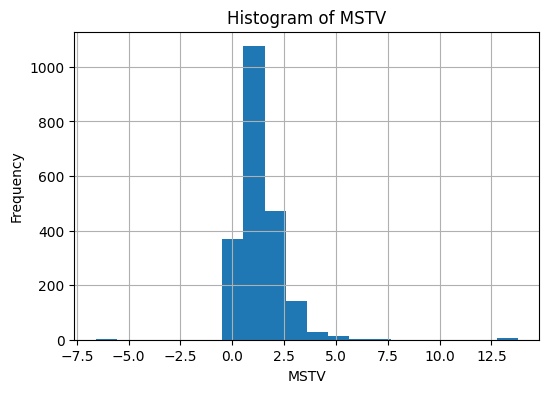

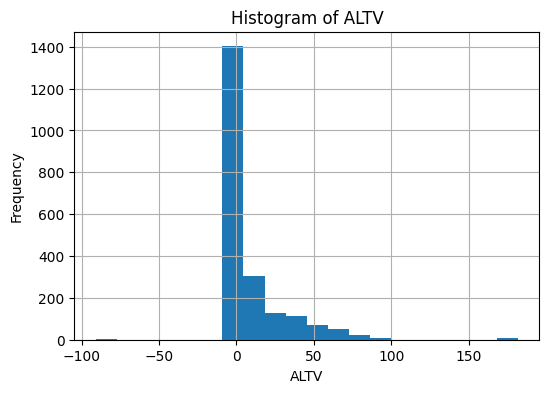

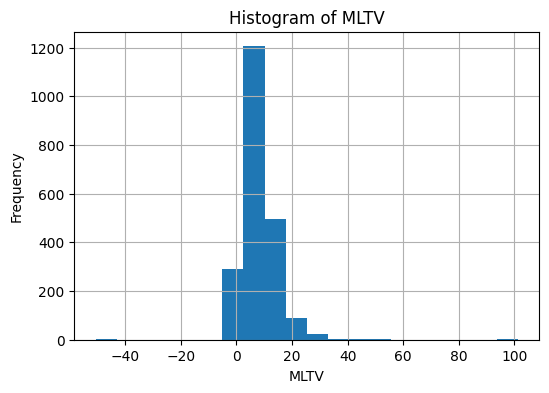

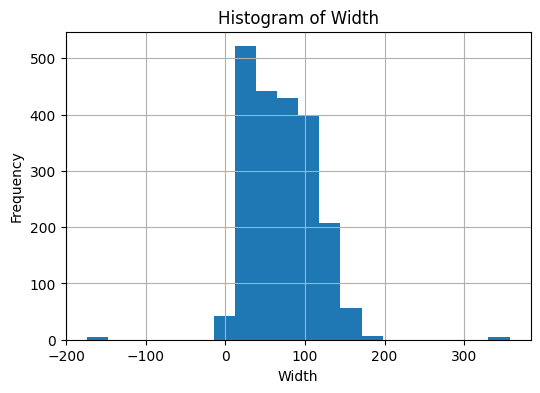

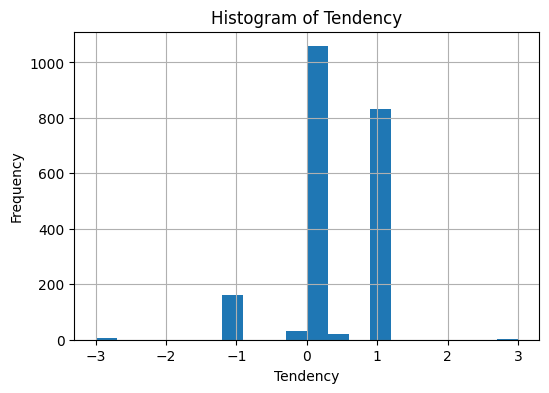

In [34]:
## Since we have already created box-plot above so we will be creating histogram.. 
for i in num_cols:
    plt.figure(figsize = (6, 4))
    df[i].hist(bins = 20)
   # plt.tight_layout()
    plt.title(f"Histogram of {i}")
    plt.xlabel(i)
    plt.ylabel("Frequency")
    plt.show()

In [35]:
## Histograms were plotted for all the numerical columns to visualize their distributions.. 
## Most variables appear right skewed with many values concentrated near zer0..
## Variables such as LB showed comparitively more symmetric distribution..

In [36]:
df.columns

Index(['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV',
       'MLTV', 'Width', 'Tendency', 'NSP'],
      dtype='object')

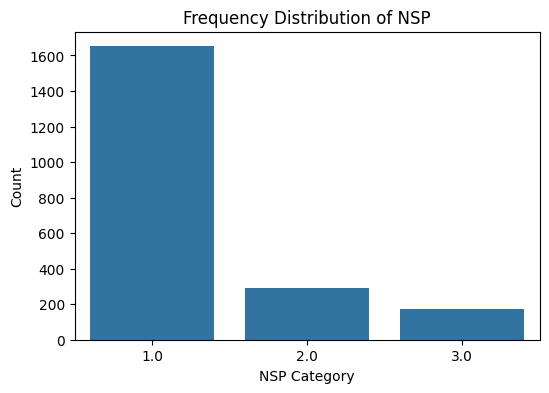

NSP
1.0    1651
2.0     293
3.0     172
Name: count, dtype: int64


In [37]:
## Bar chart for NSP (target variable) frequency distribution..
## Even though NSP is stored as a number it actually represents categories so we treat it as a categorical variable..

plt.figure(figsize = (6,4))
sns.countplot(x = "NSP", data = df)
plt.title("Frequency Distribution of NSP")
plt.xlabel("NSP Category")
plt.ylabel("Count")
plt.show()

print(df["NSP"].value_counts())

In [38]:
## The bar chart shows that the majority of the observations belong to the normal fetal state (NSP = 1.0)..
## Rest 2 categories occurs less frequently..
## This indicates a class imbalance in the dataset..
## We wont't be blindly adding synthetic data to make it classes balanced..
## Instead first we check it's impact on the model performance, then based on the outcome we act accordingly..
## Techniques like class weighing, oversampling, undersampling or synthetic data generation can be applied when necessary..
## The goal is not to achieve 50:50 class distribution, but to improve the model's ability to correctly learn and predict the minority class while maintaining generalization..

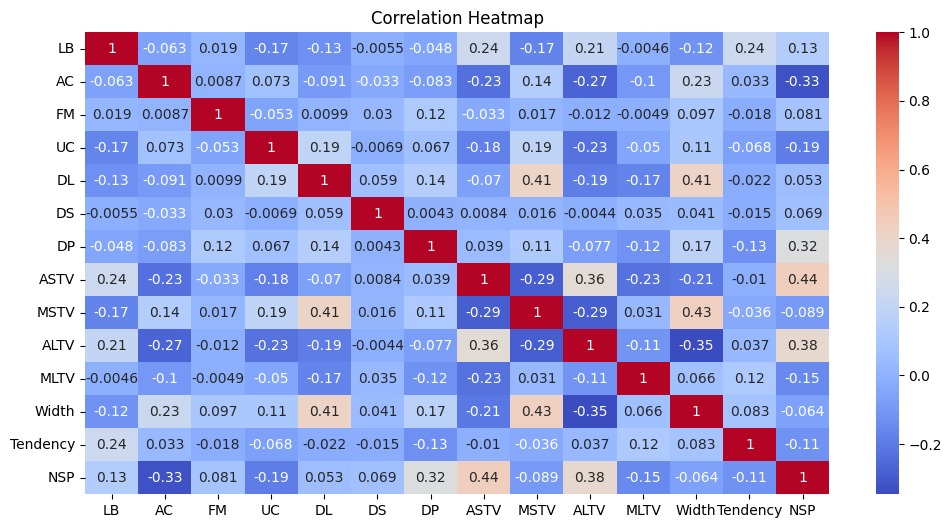

In [39]:
## correlation heatmap..

plt.figure(figsize = (12,6))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [40]:
## Most of the variables show weak correlations with each other
## Some moderate positive correlation are observed, such as correlation of ASTV, ALTV and DP with NSP..
## AC shows a moderate negative correlation with NSP..
## A few correlation also exist between input variables such as correlation between DL with width and MSTV.. 
## But overall multicollinearity seems to be on the lower side..

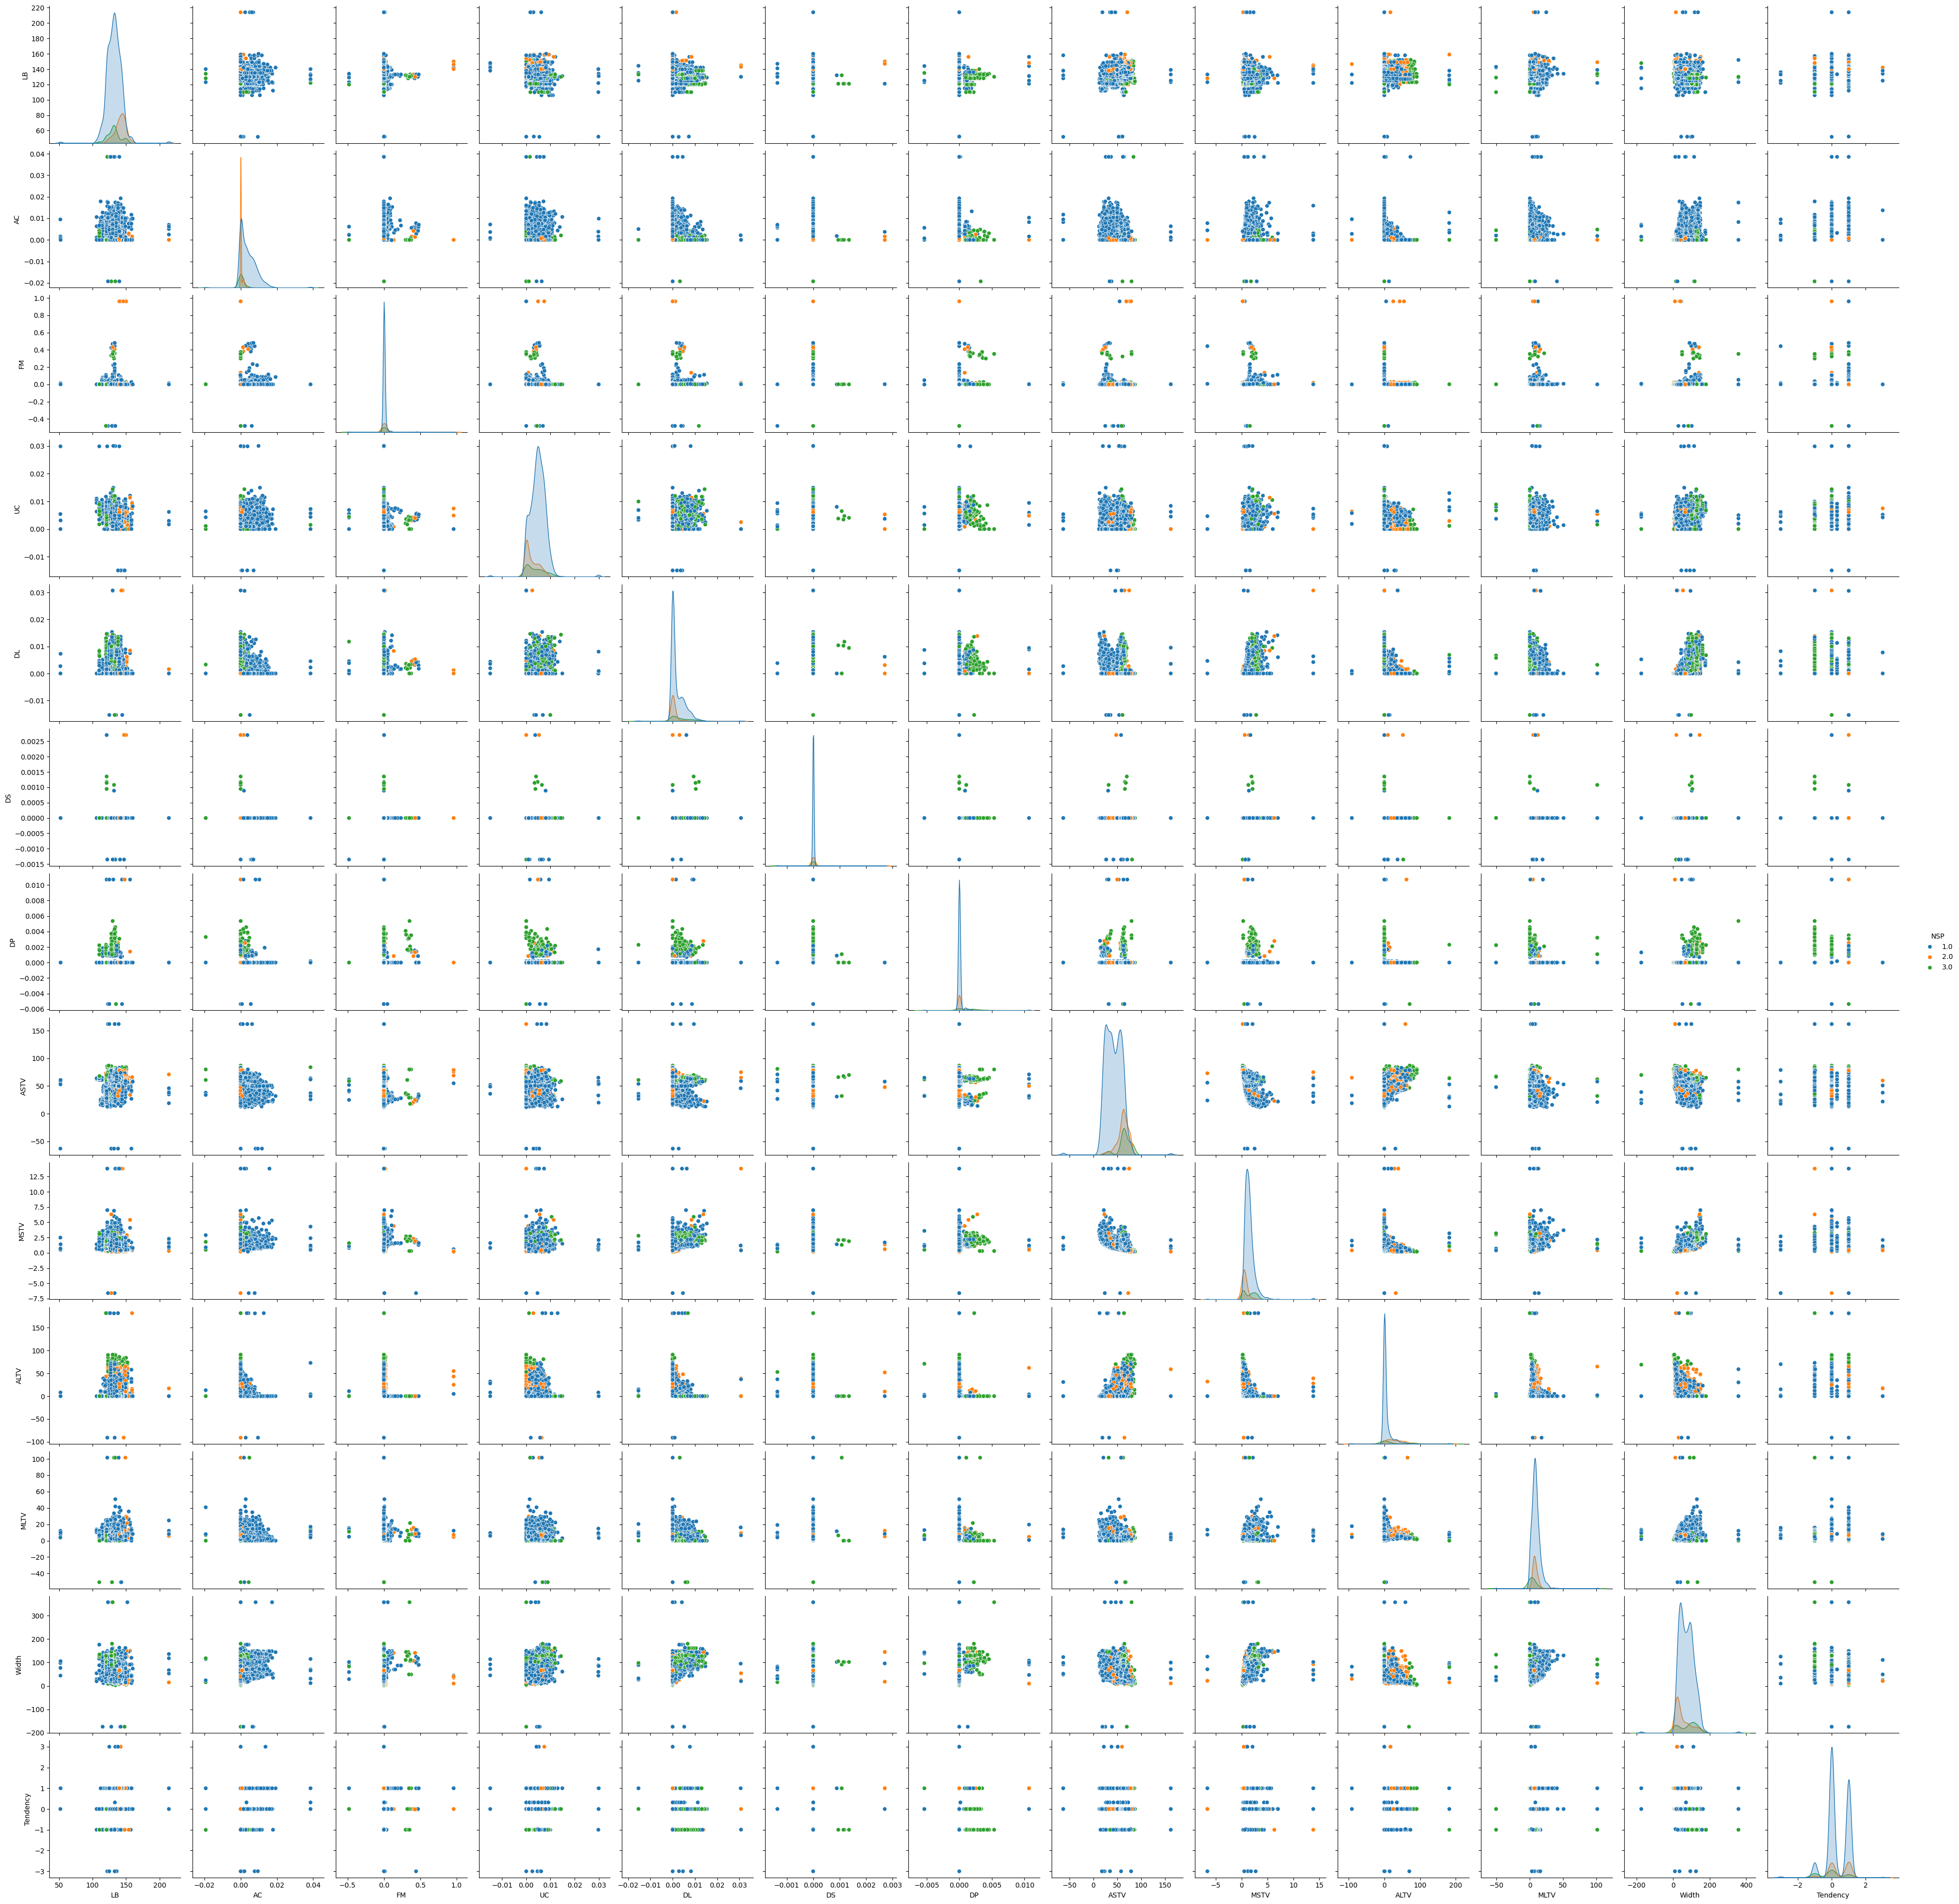

In [41]:
## pair plot for deeper insight.. 

sns.pairplot(df, hue = "NSP", height = 3)
plt.show()

In [42]:
## The pair plot appears crowded because the dataset contain 14 numerical features resulting in numerous pairwise comparisions..
## This makes individual relationships difficult to interpret..
## To enhance the readability of these features we can plot selected features seperatly by methods like feature selection, correlation based filtering etc..
## Since we have already plotted the corelation heatmap and respective histograms, we wil avoid that for now.. 

## 4.	Pattern Recognition and Insights:

In [43]:
## ●	Identify any correlations between variables and discuss their potential implications.
## ●	Look for trends or patterns over time if temporal data is available.

In [44]:
## The correlation hetmap shows that most of the variables have weak correlations, which tells us that they are relatively independent..
## A few variable shows moderate relationships with the target variable NSP ..
## ASTV, ALTV, DP shows a moderate positive correlation with NSP..they may play a crucial role in determining NSP..
## On the other hand AC shows moderate negative correlation with NSP.. shows its inversely proportion relation with NSP..
## Overall, the correlation suggest that some variables may affect the fetal health condition while most variables seems to work independently..

In [45]:
## The given dataset does not contain any temporal or time related variable..
## So its not possible to analyze trends or pattern over time in this dataset..

## 5.	Conclusion:

In [46]:
## ●	Summarize the key insights and patterns discovered through your exploratory analysis.
## ●	Discuss how these findings could impact decision-making or further analyses.

In [47]:
##  Finalsummary

## The exploratory data analysis helped in understanding the structure and distribution of the dataset..
## The statistical summary using mean, median, standard deviation and IQR provided insights about central tendency and variability in dataset.. 
## Most numerical variables showed skewed distribution and contained many zero values, this explains the presence of so many outliers..  
## The dataset being related to medical we decided not to remove these outliers caused by zeors in the records..
## The NSP (target variable) showed that most observation belong to the normal fetal state (NSP=1.0), indicating class imbalance in the dataset..
## Correlation analysis revealed that most variables have weak relationship, while a few of them (ASTV, ALTV, DP) shows moderate correlation with NSP..

In [48]:
## The findings from EDA can help us guide further analysis and model building..
## It shows the distribution of variables, presence of the outliers and relationship  between different features..
## These insights can help in selecting important variables and preparing the data properly for further analysis or building ML models..
## The observed imbalance in the NSP class is also an important point, we may need to consider it later during model training to ensure accurate predictions..
## Overall these insights can support better decision making in future analysis related to NSP..